In [100]:
import numpy as np
import matplotlib.pyplot as plt
import os

import keras
from keras import layers
# import tensorflow as tf

# import io
# import imageio
# from IPython.display import Image, display
# from ipywidgets import widgets, Layout, HBox

In [101]:
# Split into train and validation sets using indexing to optimize memory.
data = np.load("./data/data.npy")
indexes = np.arange(data.shape[0])
np.random.shuffle(indexes)
train_index = indexes[: int(0.9 * data.shape[0])]
val_index = indexes[int(0.9 * data.shape[0]) :]
train_dataset = data[train_index]
val_dataset = data[val_index]

print(train_dataset.shape)
print(val_dataset.shape)

(460, 5, 512, 512, 1)
(52, 5, 512, 512, 1)


In [102]:
# Normalize the data to the 0-1 range.
train_dataset = train_dataset / 255
val_dataset = val_dataset / 255


# We'll define a helper function to shift the frames, where
# `x` is frames 0 to n - 1, and `y` is frames 1 to n.
def create_shifted_frames(data):
    # data shape: (batch, time, height, width, channels)
    x = data[:, 0 : data.shape[1] - 1, :, :, :]
    y = data[:, 1 : data.shape[1], :, :, :]
    return x.astype(np.float32), y.astype(np.float32)

# Apply the processing function to the datasets.
x_train, y_train = create_shifted_frames(train_dataset)
x_val, y_val = create_shifted_frames(val_dataset)

# Inspect the dataset.
print("Train Dataset Shapes: " + str(x_train.shape) + ", " + str(y_train.shape))
print("Validation Dataset Shapes: " + str(x_val.shape) + ", " + str(y_val.shape))

Train Dataset Shapes: (460, 4, 512, 512, 1), (460, 4, 512, 512, 1)
Validation Dataset Shapes: (52, 4, 512, 512, 1), (52, 4, 512, 512, 1)


Displaying frames for example 361.


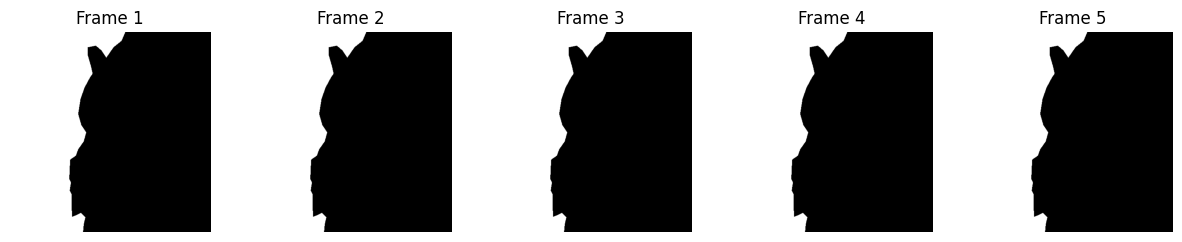

In [143]:
import numpy as np
import matplotlib.pyplot as plt

# 랜덤하게 1개 시퀀스 선택
data_choice = np.random.choice(range(len(train_dataset)), size=1)[0]
sequence = train_dataset[data_choice]  # shape: (5, 4096, 4096, 1)

# 시퀀스 길이에 맞는 subplot 생성
seq_len = sequence.shape[0]
fig, axes = plt.subplots(1, seq_len, figsize=(seq_len * 3, 3))

for idx, ax in enumerate(axes):
    frame = np.squeeze(sequence[idx])  # (4096, 4096)
    ax.imshow(frame, cmap="gray")
    ax.set_title(f"Frame {idx + 1}")
    ax.axis("off")

print(f"Displaying frames for example {data_choice}.")
plt.show()

In [104]:
# Construct the input layer with no definite frame size.
inp = layers.Input(shape=(None, *x_train.shape[2:]))

# We will construct 3 `ConvLSTM2D` layers with batch normalization,
# followed by a `Conv3D` layer for the spatiotemporal outputs.
x = layers.ConvLSTM2D(
    filters=16,
    kernel_size=(5, 5),
    padding="same",
    return_sequences=True,
    activation="relu",
)(inp)
x = layers.BatchNormalization()(x)
x = layers.ConvLSTM2D(
    filters=16,
    kernel_size=(3, 3),
    padding="same",
    return_sequences=True,
    activation="relu",
)(x)
x = layers.BatchNormalization()(x)
x = layers.ConvLSTM2D(
    filters=16,
    kernel_size=(1, 1),
    padding="same",
    return_sequences=True,
    activation="relu",
)(x)
x = layers.Conv3D(
    filters=1, kernel_size=(3, 3, 3), activation="sigmoid", padding="same"
)(x)

# Next, we will build the complete model and compile it.
model = keras.models.Model(inp, x)
model.compile(
    loss=keras.losses.binary_crossentropy,
    optimizer=keras.optimizers.Adam(),
)

In [105]:
# Define some callbacks to improve training.
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5)

# Define modifiable training hyperparameters.
epochs = 20
batch_size = 1

# Fit the model to the training data.
model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping, reduce_lr],
)

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 82ms/step - loss: 0.1511 - val_loss: 0.1779 - learning_rate: 0.0010
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0056 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0058 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0063 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0062 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0067 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0055 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 8/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0056 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 9/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step - loss: 0.0057 - val_loss: 0.0084 - learning_rate:

In [ ]:
weights_dir = '/workspace/weights'
os.makedirs(weights_dir, exist_ok=True)

model.save_weights(os.path.join(weights_dir, 'pred_wb.weights.h5'))

In [ ]:
model.load_weights(os.path.join('./weights/pred_wb.weights.h5'))

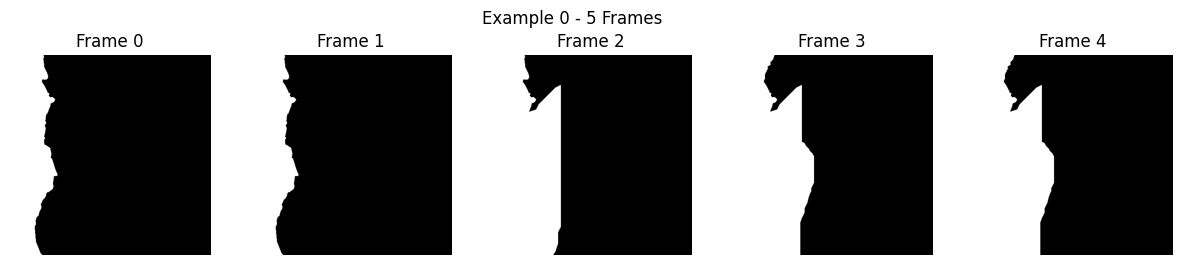

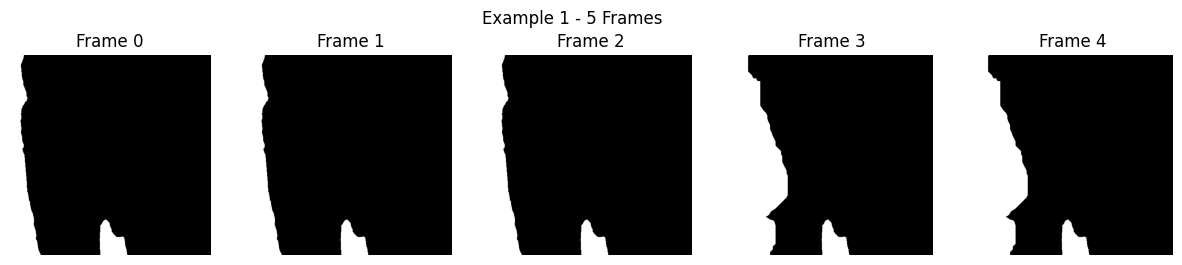

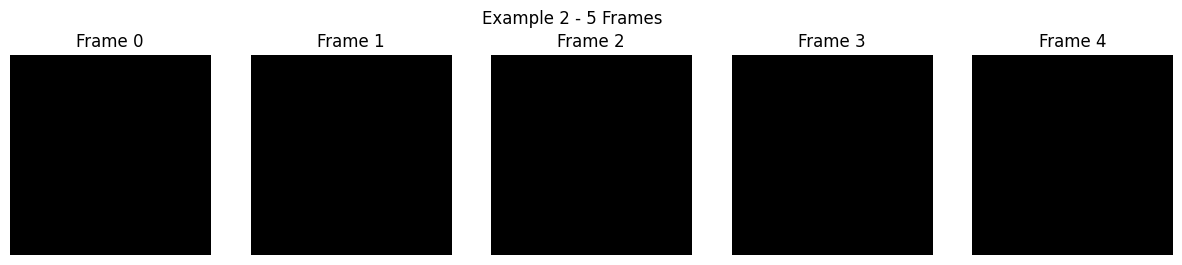

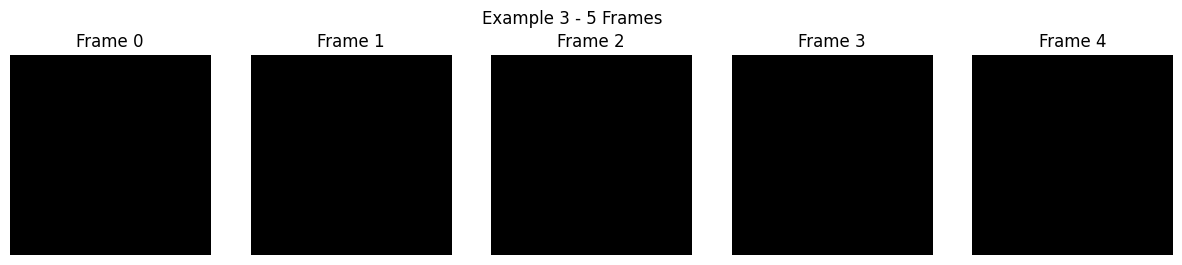

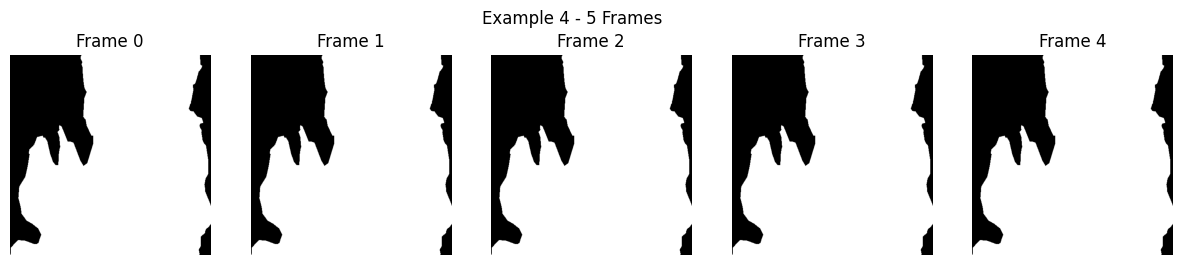

In [128]:
# Select a few random examples from the dataset.
examples = val_dataset[np.random.choice(range(len(val_dataset)), size=5)]
num_examples_to_show = min(5, len(examples))  # 최대 3개 예시만 시각화
frames_per_example = examples.shape[1]

for i in range(num_examples_to_show):
    example = examples[i]  # (seq_len, H, W, C)
    
    fig, axes = plt.subplots(1, frames_per_example, figsize=(15, 3))
    fig.suptitle(f"Example {i} - {frames_per_example} Frames")
    
    for t in range(frames_per_example):
        ax = axes[t]
        frame = example[t]
        
        # 만약 채널 축이 1이면 squeeze, 3이면 그대로
        if frame.shape[-1] == 1:
            frame_to_show = frame.squeeze(-1)
            cmap = "gray"
        else:
            frame_to_show = frame
            cmap = None
        
        ax.imshow(frame_to_show, cmap=cmap)
        ax.axis("off")
        ax.set_title(f"Frame {t}")
    
    plt.show()


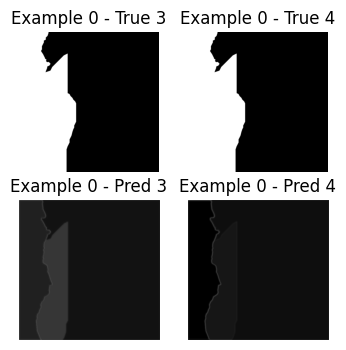

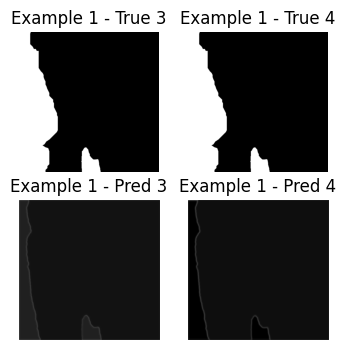

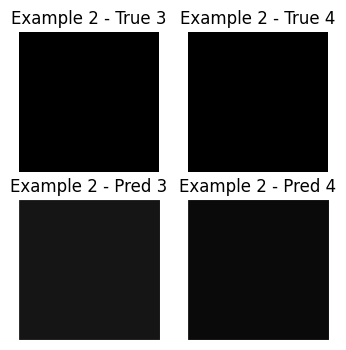

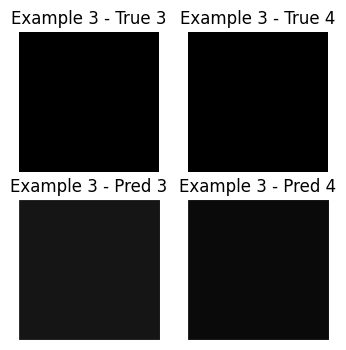

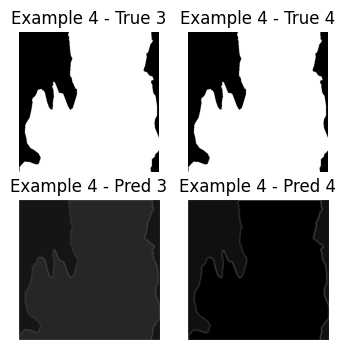

In [141]:
input_len = 3  # 초기 입력 시퀀스 길이

for ex_idx, example in enumerate(examples):
    frames = example[:input_len, ...]           # 입력 시퀀스
    original_frames = example[input_len:, ...]  # 나머지 정답 시퀀스
    num_to_predict = example.shape[0] - input_len

    # 예측 루프
    predicted_frames = []
    for _ in range(num_to_predict):
        new_prediction = model.predict(np.expand_dims(frames, axis=0), verbose=0)
        new_prediction = np.squeeze(new_prediction, axis=0)
        predicted_frame = np.expand_dims(new_prediction[-1, ...], axis=0)
        
        frames = np.concatenate((frames, predicted_frame), axis=0)
        predicted_frames.append(predicted_frame[0])

    predicted_frames = np.array(predicted_frames)

    # 시각화
    fig, axes = plt.subplots(2, max(1, num_to_predict), figsize=(2*max(1, num_to_predict), 4))
    axes = np.atleast_2d(axes)

    # True frames
    for idx, ax in enumerate(axes[0]):
        frame = original_frames[idx]
        ax.imshow(frame.squeeze(), cmap='gray')
        ax.set_title(f"Example {ex_idx} - True {idx+input_len}")
        ax.axis('off')

    # Predicted frames
    for idx, ax in enumerate(axes[1]):
        frame = predicted_frames[idx]
        ax.imshow(frame.squeeze(), cmap='gray')
        ax.set_title(f"Example {ex_idx} - Pred {idx+input_len}")
        ax.axis('off')

    plt.show()
    plt.close(fig)
